015x数据集（开源代码使用数据集），深度学习方法（resnet模型+注意力机制）

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from sklearn.manifold import trustworthiness
from scipy.stats import ks_2samp
from tqdm import tqdm

# ==========================================
# 1. 配置参数
# ==========================================
# 请确保这些文件存在
INPUT_PATHS = [
    {"tfrecords": "dichasus/dichasus-0152.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-015x.json"},
    {"tfrecords": "dichasus/dichasus-0153.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-015x.json"},
    {"tfrecords": "dichasus/dichasus-0154.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-015x.json"},
    
]

ANTENNA_COUNT = 32
SUBCARRIERS = 1024
BATCH_SIZE = 32

2026-01-25 12:53:41.706296: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-25 12:53:41.774681: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-25 12:53:43.322814: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# ==========================================
# 适配 dichasus-015x (实验室 LOS 场景)
# ==========================================
def load_dataset_015x(path, offset_path):
    offsets = None
    if os.path.exists(offset_path):
        with open(offset_path, "r") as f:
            offsets = json.load(f)
    
    def record_parse_function(proto):
        record = tf.io.parse_single_example(
            proto,
            {
                "csi": tf.io.FixedLenFeature([], tf.string, default_value=""),
                # 【改动1】必须用 "pos-lidar"。虽然有 pos-tachy，但后半程数据缺失严重。
                "pos-lidar": tf.io.FixedLenFeature([], tf.string, default_value=""), 
                "time": tf.io.FixedLenFeature([], tf.float32, default_value=0),
            },
        )

        # --- CSI 解析 ---
        # 015x 依然是 32 天线 (Main Array)
        csi = tf.io.parse_tensor(record["csi"], out_type=tf.float32)
        csi = tf.ensure_shape(csi, (32, 1024, 2)) 
        csi_complex = tf.complex(csi[:, :, 0], csi[:, :, 1])
        csi_complex = tf.signal.fftshift(csi_complex, axes=1)

        # --- Position 解析 ---
        # 【改动2】解析 pos-lidar (2D)
        # 注意：015x 的 pos-lidar 通常是序列化 Tensor (float64)，这点同 cf0x 不同 (cf0x 的 tachy 是 tensor)
        # 但有些版本的 dichasus tfrecords 中 lidar 可能是 raw bytes。
        # 建议先试 parse_tensor，如果报错再改 decode_raw。
        # 根据经验，015x 的 pos-lidar 是 parse_tensor。
        pos = tf.io.parse_tensor(record["pos-lidar"], out_type=tf.float64)
        
        # 【改动3】Lidar 只有 2D 坐标 (x, y)
        pos = tf.ensure_shape(pos, (2,)) 
        
        pos = tf.cast(pos, tf.float32)

        return csi_complex, pos

    # ... 校准和预处理逻辑与之前完全一致 ...
    def apply_calibration(csi, pos):
        if offsets:
            sto_offset = tf.tensordot(tf.constant(offsets["sto"], dtype=tf.float32), 
                                      2 * np.pi * tf.range(1024, dtype=tf.float32) / 1024.0, axes=0)
            cpo_offset = tf.tensordot(tf.constant(offsets["cpo"], dtype=tf.float32), 
                                      tf.ones(1024, dtype=tf.float32), axes=0)
            calib_factor = tf.exp(tf.complex(0.0, sto_offset + cpo_offset))
            csi = tf.multiply(csi, calib_factor)
        return csi, pos

    def preprocess_features(csi, pos):
        mag = tf.math.abs(csi)
        # LOS 场景下信号很强，对数缩放依然有效，但可以考虑调整归一化参数
        mag = tf.math.log(mag + 1e-6)
        mag = (mag - 0.0) / 5.0 
        phase = tf.math.angle(csi)
        phase = phase / np.pi
        features = tf.stack([mag, phase], axis=-1)
        return features, pos

    ds = tf.data.TFRecordDataset(path)
    ds = ds.map(record_parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(apply_calibration, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(preprocess_features, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

# ==========================================
# 主程序调用示例
# ==========================================
# 记得修改这里的路径！
INPUT_PATHS_015X = [
    {"tfrecords": "dichasus/dichasus-0152.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-015x.json"},
    {"tfrecords": "dichasus/dichasus-0153.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-015x.json"},
]

# 训练时请确保你的模型输出层是 Dense(2)，因为我们用了 pos-lidar

In [3]:
class SqueezeAndExcitation(layers.Layer):
    def __init__(self, channels, ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.avg_pool = layers.GlobalAveragePooling2D()
        self.dense1 = layers.Dense(channels // ratio, activation='relu')
        self.dense2 = layers.Dense(channels, activation='sigmoid')
        
    def call(self, inputs):
        x = self.avg_pool(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        x = tf.reshape(x, (-1, 1, 1, inputs.shape[-1]))
        return inputs * x

def build_model():
    input_shape = (ANTENNA_COUNT, SUBCARRIERS, 2)
    inputs = layers.Input(shape=input_shape)
    
    # 简单的 Conv
    x = layers.Conv2D(32, (3, 7), padding='same', strides=(1, 2))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # 残差块函数
    def res_se_block(x, filters):
        shortcut = x
        if x.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)
        
        y = layers.Conv2D(filters, (3, 3), padding='same')(x)
        y = layers.BatchNormalization()(y)
        y = layers.Activation('relu')(y)
        y = layers.Conv2D(filters, (3, 3), padding='same')(y)
        y = layers.BatchNormalization()(y)
        y = SqueezeAndExcitation(filters)(y)
        y = layers.Add()([y, shortcut])
        y = layers.Activation('relu')(y)
        return y

    x = res_se_block(x, 64)
    x = layers.MaxPooling2D((2, 2))(x)
    x = res_se_block(x, 128)
    x = layers.MaxPooling2D((2, 2))(x)
    x = res_se_block(x, 256)
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(2)(x) # 输出 x, y
    
    return models.Model(inputs=inputs, outputs=outputs)

In [4]:
full_dataset = None
for inp in INPUT_PATHS:
    ds = load_dataset_015x(inp["tfrecords"], inp["offsets"])
    full_dataset = ds if full_dataset is None else full_dataset.concatenate(ds)

print("正在统计数据集总数，请稍候...")
# 关键修复：真实统计数量，防止 ValueError
TOTAL_SAMPLES = sum(1 for _ in full_dataset)
print(f"数据集总样本数: {TOTAL_SAMPLES}")

train_size = int(0.7 * TOTAL_SAMPLES)
val_size = int(0.15 * TOTAL_SAMPLES)
test_size = TOTAL_SAMPLES - train_size - val_size

full_dataset = full_dataset.shuffle(buffer_size=2000, seed=42)
train_ds = full_dataset.take(train_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = full_dataset.skip(train_size).take(val_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = full_dataset.skip(train_size + val_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"划分: 训练 {train_size}, 验证 {val_size}, 测试 {test_size}")

I0000 00:00:1769345632.841242  483769 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43603 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:9c:00.0, compute capability: 8.9
I0000 00:00:1769345632.841755  483769 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43603 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:9d:00.0, compute capability: 8.9
I0000 00:00:1769345632.842226  483769 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43603 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:a0:00.0, compute capability: 8.9
I0000 00:00:1769345632.842631  483769 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43603 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:a4:00.0, compute capability: 8.9


正在统计数据集总数，请稍候...


2026-01-25 12:53:54.054248: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-01-25 12:54:01.486495: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


数据集总样本数: 43026
划分: 训练 30118, 验证 6453, 测试 6455


In [5]:
model = build_model()
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # mae 在这里即 mean distance error 的近似

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # 演示用 20，实际建议 50+
    callbacks=[callbacks.ReduceLROnPlateau(patience=5), callbacks.EarlyStopping(patience=10)]
)

Epoch 1/20


2026-01-25 12:54:31.028305: I external/local_xla/xla/service/service.cc:163] XLA service 0x7db2b401ec90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-25 12:54:31.028347: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2026-01-25 12:54:31.028356: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA L40S, Compute Capability 8.9
2026-01-25 12:54:31.028363: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (2): NVIDIA L40S, Compute Capability 8.9
2026-01-25 12:54:31.028369: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (3): NVIDIA L40S, Compute Capability 8.9
2026-01-25 12:54:31.216746: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-25 12:54:32.212807: I external/local_xla/xla/st

      5/Unknown 19s 35ms/step - loss: 4.9660 - mae: 1.4782

I0000 00:00:1769345684.920814  484144 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    942/Unknown 61s 45ms/step - loss: 0.7552 - mae: 0.6349

...

942/942 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0880 - mae: 0.2236

2026-01-25 13:07:41.577831: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10274665780924450969
2026-01-25 13:07:41.577905: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 17595114486415933868


942/942 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - loss: 0.0880 - mae: 0.2236 - val_loss: 0.1068 - val_mae: 0.2539 - learning_rate: 0.0010
Epoch 20/20


2026-01-25 13:07:49.585435: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10274665780924450969


942/942 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - loss: 0.0847 - mae: 0.2192 - val_loss: 0.0786 - val_mae: 0.2115 - learning_rate: 0.0010


In [6]:
# ==========================================
# 修复后的评估与可视化代码 (独立运行版)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from sklearn.manifold import trustworthiness
from scipy.stats import ks_2samp
import numpy as np
import tensorflow as tf

# 1. 【修复 NameError】定义采样数
# 用于计算耗时的流形指标(TW/CT)和绘制散点图(避免过于密集)
EVAL_SAMPLES = 2000 

print("正在准备全量评估数据 (可能需要一点时间)...")

# 2. 重新遍历测试集，确保获取对应的 y_pred, y_true 和 高维特征 X
y_true_list = []
y_pred_list = []
X_features_list = [] # 用于计算 TW/CT

# 计数器，用于控制仅提取部分高维特征以节省内存
count = 0 

for batch_x, batch_y in test_ds:
    # 预测全量数据
    preds = model.predict(batch_x, verbose=0)
    
    y_true_list.append(batch_y.numpy())
    y_pred_list.append(preds)
    
    # 仅收集前 EVAL_SAMPLES 个样本的特征用于流形计算
    if count < EVAL_SAMPLES:
        # 提取幅度通道 (batch, 32, 1024, 2) -> 取 index 0 -> Flatten
        # 这里的 batch_x[..., 0] 对应幅度信息
        flat_feats = tf.reshape(batch_x[..., 0], (batch_x.shape[0], -1)).numpy()
        X_features_list.append(flat_feats)
        count += batch_x.shape[0]

# 合并为 Numpy 数组
y_true = np.concatenate(y_true_list, axis=0) # 全量真实值
y_pred = np.concatenate(y_pred_list, axis=0) # 全量预测值

# 截取用于流形指标计算的子集
# 注意：X_features_list 可能比 EVAL_SAMPLES 稍微多一点(因为是按batch添加的)，这里强制截断对齐
min_len = min(len(y_pred), EVAL_SAMPLES)
X_high_dim = np.concatenate(X_features_list, axis=0)[:min_len]
y_pred_sub = y_pred[:min_len] # 对应的低维嵌入子集
y_true_sub = y_true[:min_len] # 对应的真实值子集

print(f"数据准备完毕。全量样本数: {len(y_pred)}, 流形评估子集数: {min_len}")

# --- 3. 计算各项指标 ---

# (1) MAE (平均定位误差) - 【使用全量 y_pred】
errors = np.linalg.norm(y_true - y_pred, axis=1)
mae = np.mean(errors)

# (2) KS (分布一致性) - 【使用全量 y_pred】
ks_x = ks_2samp(y_true[:, 0], y_pred[:, 0]).statistic
ks_y = ks_2samp(y_true[:, 1], y_pred[:, 1]).statistic
ks_score = (ks_x + ks_y) / 2.0

# (3) TW & CT (流形质量) - 【使用子集，否则计算量太大】
print("正在计算流形指标 (TW/CT)...")
# TW: 衡量高维空间的邻居是否被保留到了低维 (Trustworthiness)
tw_score = trustworthiness(X_high_dim, y_pred_sub, n_neighbors=5, metric='euclidean')

# CT: 衡量低维空间的邻居是否也是高维的 (Continuity)
# 注意：trustworthiness 函数参数反过来传就是 Continuity
ct_score = trustworthiness(y_pred_sub, X_high_dim, n_neighbors=5, metric='euclidean')

print("\n" + "="*40)
print("           核心评估指标汇报")
print("="*40)
print(f"MAE (平均定位误差)    : {mae:.4f} m  (全量数据)")
print(f"KS  (分布差异统计量)  : {ks_score:.4f} (全量数据)")
print(f"TW  (可信度/邻域保持): {tw_score:.4f} (子集评估)")
print(f"CT  (连续性/流形断裂): {ct_score:.4f} (子集评估)")
print("="*40)



正在准备全量评估数据 (可能需要一点时间)...


2026-01-25 13:18:40.517494: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-25 13:18:40.953600: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_346', 20 bytes spill stores, 20 bytes spill loads



数据准备完毕。全量样本数: 6455, 流形评估子集数: 2000
正在计算流形指标 (TW/CT)...

           核心评估指标汇报
MAE (平均定位误差)    : 0.2705 m  (全量数据)
KS  (分布差异统计量)  : 0.0776 (全量数据)
TW  (可信度/邻域保持): 0.6555 (子集评估)
CT  (连续性/流形断裂): 0.8731 (子集评估)


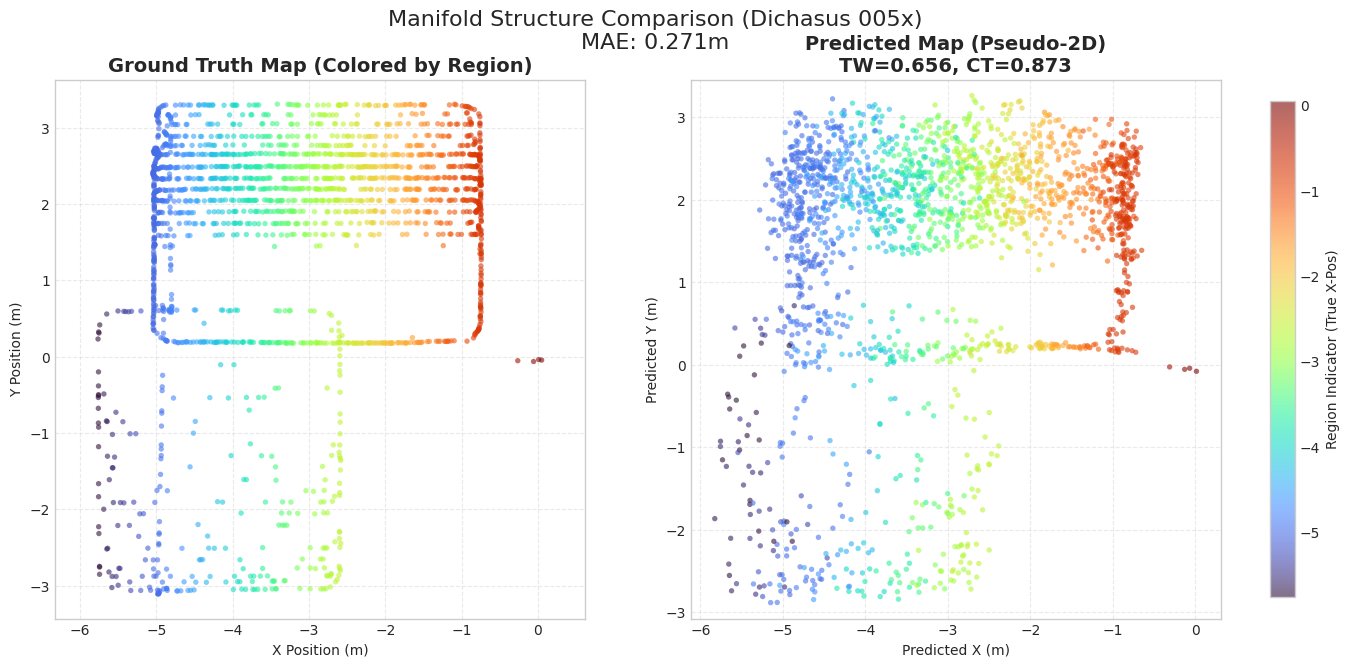

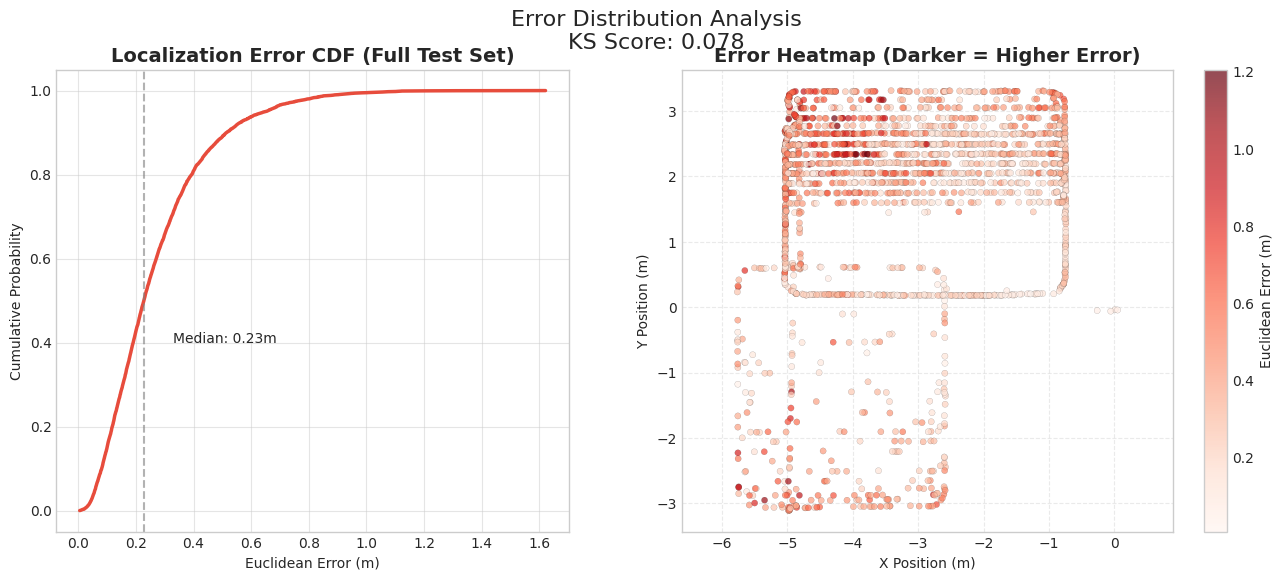

In [7]:
# --- 4. 绘图部分 ---
# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')

# 颜色映射：根据真实坐标的 X 轴位置生成颜色，形成彩虹带
# 使用子集绘图以保持图表清晰，且对应 TW/CT 的样本
colors = y_true_sub[:, 0] 

# ========== 图表 1: 区域映射对比 (Maps Comparison) ==========
fig1 = plt.figure(figsize=(16, 7))
gs1 = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# 子图 1: Ground Truth (真实流形)
ax1 = plt.subplot(gs1[0])
sc1 = ax1.scatter(y_true_sub[:, 0], y_true_sub[:, 1], c=colors, cmap='turbo', s=15, alpha=0.6, edgecolors='none')
ax1.set_title(f'Ground Truth Map (Colored by Region)', fontsize=14, fontweight='bold')
ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.axis('equal')
ax1.grid(True, linestyle='--', alpha=0.4)

# 子图 2: Prediction (预测流形)
ax2 = plt.subplot(gs1[1])
sc2 = ax2.scatter(y_pred_sub[:, 0], y_pred_sub[:, 1], c=colors, cmap='turbo', s=15, alpha=0.6, edgecolors='none')
ax2.set_title(f'Predicted Map (Pseudo-2D)\nTW={tw_score:.3f}, CT={ct_score:.3f}', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted X (m)')
ax2.set_ylabel('Predicted Y (m)')
ax2.axis('equal')
ax2.grid(True, linestyle='--', alpha=0.4)

# 添加颜色条
cbar = fig1.colorbar(sc1, ax=[ax1, ax2], fraction=0.02, pad=0.04)
cbar.set_label('Region Indicator (True X-Pos)', fontsize=10)

plt.suptitle(f"Manifold Structure Comparison (Dichasus 005x)\nMAE: {mae:.3f}m", fontsize=16)
plt.show()

# ========== 图表 2: 误差分析 (Error Analysis) ==========
fig2 = plt.figure(figsize=(16, 6))
gs2 = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2])

# 子图 1: CDF 曲线 (累积分布函数) - 【使用全量 errors】
sorted_errors = np.sort(errors)
p = 1. * np.arange(len(errors)) / (len(errors) - 1)
ax3 = plt.subplot(gs2[0])
ax3.plot(sorted_errors, p, linewidth=2.5, color='#e74c3c')
# 标注中位数和90%分位
p50 = sorted_errors[int(len(errors)*0.5)]
p90 = sorted_errors[int(len(errors)*0.9)]
ax3.axvline(p50, color='gray', linestyle='--', alpha=0.6)
ax3.text(p50+0.1, 0.4, f'Median: {p50:.2f}m', fontsize=10)
ax3.set_title('Localization Error CDF (Full Test Set)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Euclidean Error (m)')
ax3.set_ylabel('Cumulative Probability')
ax3.grid(True, alpha=0.5)

# 子图 2: 误差空间分布热力图 - 【使用子集绘图】
ax4 = plt.subplot(gs2[1])
# 颜色深浅表示误差大小
error_subset = np.linalg.norm(y_true_sub - y_pred_sub, axis=1)
sc4 = ax4.scatter(y_true_sub[:, 0], y_true_sub[:, 1], c=error_subset, cmap='Reds', s=20, alpha=0.7, edgecolors='k', linewidth=0.1)
ax4.set_title('Error Heatmap (Darker = Higher Error)', fontsize=14, fontweight='bold')
ax4.set_xlabel('X Position (m)')
ax4.set_ylabel('Y Position (m)')
ax4.axis('equal')
ax4.grid(True, linestyle='--', alpha=0.4)

cbar4 = fig2.colorbar(sc4, ax=ax4)
cbar4.set_label('Euclidean Error (m)', fontsize=10)

plt.suptitle(f"Error Distribution Analysis\nKS Score: {ks_score:.3f}", fontsize=16)
plt.show()